# MCMC Benchmark on the Rosenbrock function sampling

In [11]:
import warnings
import torch
from torch import Tensor
from geodesic_toolbox import ImplicitFHMCUnbiased, ImplicitRHMCSampler, RosenbrockDualRanders, RosenbrockSoftAbs
import tqdm
from botorch.exceptions import OptimizationWarning

torch.set_default_dtype(torch.float64)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=OptimizationWarning)
warnings.filterwarnings("ignore", message=".*not contained to the unit cube.*")
warnings.filterwarnings("ignore", message=".*torch.float32.*")

In [12]:
from botorch.models import SingleTaskGP
from botorch.models.transforms.input import Normalize
from botorch.acquisition import qLogExpectedImprovement
from botorch.optim import optimize_acqf
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood

In [13]:
class RosenbrockFHMCUnbiased(ImplicitFHMCUnbiased):
    def __init__(self, l: int, N_fx: int, gamma: float, N_run: int,
                 bounds: float = 1e3, std_0: float = 1., beta_0: float = 1.,
                 pbar: bool = False, skip_acceptance: bool = False,
                 reduced_flip: bool = True, alpha: float = 1., beta : float = 1.):
        randers_cometric = RosenbrockDualRanders(alpha=alpha, beta = beta)
        super().__init__(
            randers_cometric=randers_cometric,
            l=l, N_fx=N_fx, gamma=gamma, N_run=N_run,
            bounds=bounds, std_0=std_0, beta_0=beta_0,
            pbar=pbar, skip_acceptance=skip_acceptance,
            reduced_flip=reduced_flip,
        )

    def U(self, z):
        x, y = z[:, 0], z[:, 1]
        return (100*(y - x**2)**2 + (1 - x)**2) / 20
    
    def K(self, p: Tensor, z: Tensor) -> Tensor:
        d   = z.shape[1]
        eps = self.randers_cometric.epsilon
        _, w_star, G_star = self.randers_cometric._shared(z)

        v_norm = torch.einsum("bi,bij,bj->b", p, G_star, p).sqrt()
        F_star = v_norm + torch.einsum("bi,bi->b", w_star, p)
        F_star_sq = F_star ** 2 + eps ** 2

        L = torch.linalg.cholesky(G_star)
        y = torch.linalg.solve_triangular(L, w_star.unsqueeze(-1), upper=False).squeeze(-1)
        alpha = torch.einsum("bi,bi->b", y, y)
        logdet_G_star = 2.0 * torch.diagonal(L, dim1=-2, dim2=-1).log().sum(-1)

        return (0.5 * F_star_sq
                - 0.5 * (d + 1) * torch.log1p(-alpha)
                - 0.5 * logdet_G_star
                + 0.5 * d * self.log2pi)

    def H(self, z: Tensor, p: Tensor) -> Tensor:
        return self.U(z) + self.K(p, z)

    def H_tilde(self, z: Tensor, p: Tensor) -> Tensor:
        d   = z.shape[1]
        eps = self.randers_cometric.epsilon

        G_inv, w_star, G_star = self.randers_cometric._shared(z)  

        L = torch.linalg.cholesky(G_star)
        y = torch.linalg.solve_triangular(L, w_star.unsqueeze(-1), upper=False).squeeze(-1)
        b_sq = torch.einsum("bi,bi->b", y, y) 
        alpha_s = 1.0 - b_sq
        logdet_G_star = 2.0 * torch.diagonal(L, dim1=-2, dim2=-1).log().sum(-1)

        log_sigma_BH  = -0.5 * logdet_G_star
        p_Ginv_p = torch.einsum("bi,bij,bj->b", p, G_inv, p)
        wstar_p  = torch.einsum("bi,bi->b", w_star, p)  

        riem_norm = (wstar_p**2 + p_Ginv_p / alpha_s).sqrt()
        F_star_sq = (riem_norm + wstar_p)**2 + eps**2
        log_randers_factor = torch.log1p(wstar_p / riem_norm)

        return (
            self.U(z)
            + 0.5  * F_star_sq
            - (d + 1) * log_randers_factor
            + log_sigma_BH
            + 0.5 * d * self.log2pi
        )


class RosenbrockRHMC(ImplicitRHMCSampler):
    """RHMC on the Rosenbrock density using a SoftAbs Riemannian cometric."""

    def __init__(self, l: int, N_fx: int, gamma: float, N_run: int,
                 alpha: float = 1.0, bounds: float = 1e3, std_0: float = 1.,
                 beta_0: float = 1., pbar: bool = False, skip_acceptance: bool = False):
        cometric = RosenbrockSoftAbs(alpha=alpha)
        super().__init__(
            cometric=cometric, l=l, N_fx=N_fx, gamma=gamma, N_run=N_run,
            bounds=bounds, std_0=std_0, beta_0=beta_0,
            pbar=pbar, skip_acceptance=skip_acceptance,
        )

    def U(self, z: Tensor) -> Tensor:
        x, y = z[:, 0], z[:, 1]
        return (100*(y - x**2)**2 + (1 - x)**2) / 20

## Bayesian Hyperparameter Optimizer

The objective is to find the hyperparameter that optimize the minESS. We define the objective function bellow.

In [14]:
def acf(chain: Tensor) -> Tensor:
    """Return biased autocovariance estimate via FFT — O(N log N).

    Equivalent to the direct estimator (1/N) * sum_{n} x[n] * x[n+m],
    computed using the Wiener-Khinchin theorem.

    Args:
        chain (Tensor): shape (N, d)

    Returns:
        Tensor: autocovariance at lags 0..N-1, shape (N, d)
    """
    N = chain.shape[0]
    norm_chain = chain - chain.mean(dim=0)
    # Zero-pad to 2N to get linear (not circular) correlation
    f     = torch.fft.rfft(norm_chain, n=2 * N, dim=0)
    power = f.real ** 2 + f.imag ** 2
    return torch.fft.irfft(power, n=2 * N, dim=0)[:N] / N


def ess(chain: Tensor) -> Tensor:
    """Returns effective sample size per dimension.

    Args:
        chain (Tensor): shape (N_run, d) or (B, N_run, d)

    Returns:
        Tensor: shape (d,) or (B, d)
    """
    if chain.dim() == 3:
        return torch.stack([ess(chain[b]) for b in range(chain.shape[0])])
    N = chain.shape[0]
    gamma_vals = acf(chain)
    var   = gamma_vals[0]
    stuck = var.abs() < 1e-10
    rho   = gamma_vals / var.abs().clamp(min=1e-10).unsqueeze(0)
    positive  = (rho[1:] > 0).cumprod(dim=0)
    ess_vals  = N / (1 + 2 * (rho[1:] * positive).sum(dim=0))
    return torch.where(stuck, torch.ones_like(ess_vals), ess_vals)


def gelman_rubin(traj: Tensor) -> Tensor:
    """R-hat convergence diagnostic per dimension. Values near 1.0 indicate convergence.

    Args:
        traj (Tensor): shape (B, N, d) — B chains of N samples

    Returns:
        Tensor: R-hat per dimension, shape (d,)
    """
    B, N, d = traj.shape
    if B < 2:
        return torch.ones(d)
    chain_means = traj.mean(dim=1)            # (B, d)
    grand_mean  = chain_means.mean(dim=0)     # (d,)
    W     = (traj - chain_means.unsqueeze(1)).pow(2).sum(dim=(0, 1)) / (B * (N - 1))
    B_hat = N / (B - 1) * (chain_means - grand_mean).pow(2).sum(dim=0)
    var_hat = (N - 1) / N * W + B_hat / N
    return (var_hat / W.clamp(min=1e-10)).sqrt()


def min_ess_per_step(chain: Tensor, l: int, N_run: int) -> Tensor:
    """Returns the minimum ESS across dimensions, normalised by total number of leapfrog steps.

    Args:
        chain (Tensor): shape (N_run, d) or (B, N_run, d)
        l (int): number of leapfrog steps per sample
        N_run (int): number of samples

    Returns:
        Tensor: scalar
    """
    return ess(chain).min() / (N_run * l)


def target_function(
    parameters      : Tensor,
    sampler_factory : callable,
    objective_fn    : callable,
    N_batch         : int = 10,
    N_run           : int = 10,
) -> Tensor:
    """Runs the sampler and returns the objective value.

    Args:
        parameters (Tensor): shape (1, d) or (d,) — hyperparameters for the sampler
        sampler_factory (callable): (parameters, N_run) -> sampler instance
        objective_fn (callable): (traj, parameters) -> scalar Tensor
        N_batch (int): number of parallel chains
        N_run (int): number of samples per chain

    Returns:
        Tensor: shape (1,), objective to maximise
    """
    parameters = parameters.squeeze()
    sampler = sampler_factory(parameters, N_run)
    z_0  = torch.randn(N_batch, 2)
    traj = sampler.sample(z_0, return_traj=True, progress=False)
    if torch.isnan(traj).any():
        return torch.tensor([0.0])
    return objective_fn(traj, parameters).unsqueeze(0)


In [15]:
# ── Sampler factories ────────────────────────────────────────────────────────
# Each factory takes (parameters: Tensor, N_run: int) and returns a sampler.
# gamma is stored in log10-scale so the GP explores small values as carefully
# as large ones. The factory converts back with 10**p before calling the sampler.

def make_fhmc_unbiased_factory(reduced_flip: bool = True):
    """Parameters: [l, log10_gamma, beta]"""
    def factory(parameters: Tensor, N_run: int):
        p = parameters.squeeze()
        return RosenbrockFHMCUnbiased(
            l=round(p[0].item()), N_fx=6,
            gamma=10 ** p[1].item(), N_run=N_run,
            beta=p[2].item(), reduced_flip=reduced_flip,
        )
    return factory


def make_rhmc_factory():
    """Parameters: [l, log10_gamma]"""
    def factory(parameters: Tensor, N_run: int):
        p = parameters.squeeze()
        return RosenbrockRHMC(
            l=round(p[0].item()), N_fx=6,
            gamma=10 ** p[1].item(), N_run=N_run,
        )
    return factory


# ── Objective functions ───────────────────────────────────────────────────────

def min_ess_objective(traj: Tensor, parameters: Tensor) -> Tensor:
    """Mean of per-chain minESS (min taken over dimensions)."""
    return ess(traj).min(dim=-1).values.mean()


# ── Ready-to-use configs ──────────────────────────────────────────────────────
# gamma bounds in log10-scale: 10^-3 = 0.001  to  10^-0.3 ≈ 0.5

RHMC_CONFIG = {
    "sampler_factory" : make_rhmc_factory(),
    "objective_fn"    : min_ess_objective,
    "bounds"          : torch.tensor([[1., -3.], [15., -0.3]]),
    "param_names"     : ["l", "log10_gamma"],
    "discrete_dims"   : [0],
}

FHMC_REDUCED = {
    "sampler_factory" : make_fhmc_unbiased_factory(reduced_flip=True),
    "objective_fn"    : min_ess_objective,
    "bounds"          : torch.tensor([[1., -3., 0.], [15., -0.3, 1.]]),
    "param_names"     : ["l", "log10_gamma", "beta"],
    "discrete_dims"   : [0],
}

FHMC_NO_FLIP = {
    "sampler_factory" : make_fhmc_unbiased_factory(reduced_flip=False),
    "objective_fn"    : min_ess_objective,
    "bounds"          : torch.tensor([[1., -3., 0.], [15., -0.3, 1.]]),
    "param_names"     : ["l", "log10_gamma", "beta"],
    "discrete_dims"   : [0],
}


Initialization of parameters for Bayesian Optimization 

In [16]:
def generate_initial_data(
    n               : int,
    bounds          : Tensor,
    sampler_factory : callable,
    objective_fn    : callable,
    param_names     : list = None,
    discrete_dims   : list = None,
    N_batch         : int = 10,
    N_run           : int = 10,
):
    """Evaluates target_function at n random parameter sets to seed the GP.

    Args:
        n (int): number of initial points
        bounds (Tensor): shape (2, d)
        sampler_factory (callable): (parameters, N_run) -> sampler
        objective_fn (callable): (traj, parameters) -> scalar Tensor
        param_names (list): parameter names for display
        discrete_dims (list): indices of integer-valued parameters
        N_batch (int): number of parallel chains per evaluation
        N_run (int): length of each chain

    Returns:
        train_X (Tensor): shape (n, d)
        train_Y (Tensor): shape (n, 1)
        best_observed_value (float)
    """
    d = bounds.shape[1]
    train_X = bounds[0] + (bounds[1] - bounds[0]) * torch.rand(n, d)
    if discrete_dims:
        for dim in discrete_dims:
            train_X[:, dim] = train_X[:, dim].round()

    results = []
    pbar = tqdm.tqdm(range(n), desc="Initial data")
    for i in pbar:
        postfix = _params_postfix(train_X[i], param_names, discrete_dims)
        pbar.set_postfix(**postfix)
        results.append(target_function(train_X[i], sampler_factory, objective_fn, N_batch=N_batch, N_run=N_run))
    train_Y = torch.stack(results)

    return train_X, train_Y, train_Y.max().item()


def _params_postfix(parameters: Tensor, param_names: list, discrete_dims: list) -> dict:
    """Builds a tqdm postfix dict from a parameter tensor.
    
    log10_* parameters are converted back to their natural scale for display.
    """
    names = param_names or [f"p{i}" for i in range(parameters.shape[0])]
    postfix = {}
    for i, name in enumerate(names):
        val = parameters[i].item()
        if name.startswith("log10_"):
            postfix[name[len("log10_"):]] = f"{10 ** val:.4f}"
        elif discrete_dims and i in discrete_dims:
            postfix[name] = round(val)
        else:
            postfix[name] = f"{val:.3f}"
    return postfix


In [17]:
def gen_next_points(init_x : Tensor, init_y : Tensor, best_y : Tensor, bounds : Tensor, n_points : int = 1) -> Tensor:
    d = bounds.shape[-1]
    single_model = SingleTaskGP(
        init_x,
        init_y,
        input_transform=Normalize(d=d, bounds=bounds)
    )
    mll = ExactMarginalLogLikelihood(single_model.likelihood, single_model)
    fit_gpytorch_mll(mll)
    EI = qLogExpectedImprovement(model=single_model, best_f=best_y)
    candidates, _ = optimize_acqf(
        acq_function=EI, 
        bounds=bounds, 
        q=n_points, 
        num_restarts=200, 
        raw_samples=512 
    )
    return candidates


In [18]:
def run_bayesian_optimization(
    bounds          : Tensor,
    sampler_factory : callable,
    objective_fn    : callable,
    param_names     : list = None,
    discrete_dims   : list = None,
    n_init          : int = 10,
    n_opt           : int = 10,
    N_batch         : int = 10,
    N_run           : int = 10,
) -> tuple:
    """Run Bayesian optimization over sampler hyperparameters.

    Args:
        bounds (Tensor): shape (2, d) — lower and upper bounds
        sampler_factory (callable): (parameters, N_run) -> sampler
        objective_fn (callable): (traj, parameters) -> scalar Tensor
        param_names (list): parameter names for display
        discrete_dims (list): indices of integer-valued parameters
        n_init (int): number of initial random evaluations
        n_opt (int): number of BO iterations
        N_batch (int): number of parallel chains per evaluation
        N_run (int): length of each chain

    Returns:
        best_x (Tensor): best parameters found, shape (d,)
        best_y (float): best objective value
    """
    train_x, train_y, best_y = generate_initial_data(
        n_init, bounds, sampler_factory, objective_fn,
        param_names=param_names, discrete_dims=discrete_dims,
        N_batch=N_batch, N_run=N_run,
    )

    pbar = tqdm.tqdm(range(n_opt), desc="BO iterations")
    for i in pbar:
        candidates = gen_next_points(train_x, train_y, best_y, bounds)
        postfix = _params_postfix(candidates.squeeze(), param_names, discrete_dims)
        pbar.set_postfix(**postfix, best=f"{best_y:.4f}")
        new_y = target_function(candidates, sampler_factory, objective_fn, N_batch=N_batch, N_run=N_run)
        train_x = torch.cat([train_x, candidates])
        train_y = torch.cat([train_y, new_y.unsqueeze(0)])
        best_y = train_y.max().item()
        param_str = ", ".join(f"{k}={v}" for k, v in postfix.items())
        tqdm.tqdm.write(f"  iter {i+1:2d} | {param_str} | best={best_y:.4f}")

    best_idx = train_y.squeeze().argmax()
    return train_x[best_idx], best_y


## Benchmark: RHMC vs FHMC (no flip) vs FHMC (reduced flip)

In [19]:
import time

def compute_diagnostics(
    traj            : Tensor,
    sampler,
    elapsed         : float,
    acceptance_rate : float,
    flip_rate       : float = None,
) -> dict:
    """Compute chain diagnostics from a trajectory.

    Args:
        traj (Tensor): shape (B, N_run+1, d) — includes initial sample z_0
        sampler: instance with .U(z), .l, .N_run attributes
        elapsed (float): wall-clock seconds for the sampling run
        acceptance_rate (float): fraction of accepted proposals
        flip_rate (float): fraction of momentum flips (FHMC only, else None)

    Returns:
        dict of scalar diagnostics:
            acceptance_rate, [flip_rate], min_ess, ess_per_step, ess_per_second,
            ebfmi (proxy via potential energy), rhat_max
    """
    B, _, d = traj.shape
    samples = traj[:, 1:]              # (B, N_run, d) — drop initial z_0
    N_run, l = sampler.N_run, sampler.l

    ess_vals = ess(samples)            # (B, d)
    min_ess  = ess_vals.min(dim=-1).values.mean().item()

    # EBFMI: proxy via potential energy U (true EBFMI would use total Hamiltonian H=U+K)
    U_vals     = sampler.U(samples.reshape(-1, d)).reshape(B, N_run)   # (B, N_run)
    delta_U_sq = (U_vals[:, 1:] - U_vals[:, :-1]).pow(2)               # (B, N_run-1)
    ebfmi_val  = (delta_U_sq.mean(dim=1) / U_vals.var(dim=1).clamp(min=1e-10)).mean().item()

    rhat = gelman_rubin(samples)       # (d,)

    diag = {
        "acceptance_rate" : acceptance_rate,
        "min_ess"         : min_ess,
        "ess_per_step"    : min_ess / (N_run * l),
        "ess_per_second"  : min_ess / elapsed,
        "ebfmi"           : ebfmi_val,
        "rhat_max"        : rhat.max().item(),
    }
    if flip_rate is not None:
        diag["flip_rate"] = flip_rate
    return diag


def run_diagnostics(best_x: Tensor, cfg: dict, N_batch: int = 20, N_run: int = 500) -> dict:
    """Run sampler with optimal parameters and return chain diagnostics.

    Args:
        best_x (Tensor): optimal parameters, shape (d,)
        cfg (dict): algorithm config with 'sampler_factory' key
        N_batch (int): number of parallel chains for the diagnostic run
        N_run (int): chain length for the diagnostic run
    """
    sampler   = cfg["sampler_factory"](best_x, N_run)
    z_0       = torch.randn(N_batch, 2)
    has_flip  = hasattr(sampler, "reduced_flip")

    t0 = time.perf_counter()
    if has_flip:
        traj, acc_rate, flip_rate = sampler.sample(
            z_0, return_traj=True, progress=True, return_acceptance=True, return_flip=True
        )
    else:
        traj, acc_rate = sampler.sample(
            z_0, return_traj=True, progress=True, return_acceptance=True
        )
        flip_rate = None
    elapsed = time.perf_counter() - t0

    return compute_diagnostics(traj, sampler, elapsed, acc_rate, flip_rate)


In [20]:
ALGORITHMS = {
    "RHMC"         : RHMC_CONFIG,
    "FHMC_NO_FLIP" : FHMC_NO_FLIP,
    "FHMC_REDUCED" : FHMC_REDUCED,
}

BO_KWARGS   = dict(n_init=2, n_opt=5, N_batch=5, N_run=10)
DIAG_KWARGS = dict(N_batch=5, N_run=2)

optimal_params  = {}
all_diagnostics = {}

for name, cfg in ALGORITHMS.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    best_x, best_y = run_bayesian_optimization(**cfg, **BO_KWARGS)
    optimal_params[name] = {
        "params" : {n: best_x[i].item() for i, n in enumerate(cfg["param_names"])},
        "min_ess": best_y,
    }
    print(f"  Running diagnostics...")
    all_diagnostics[name] = run_diagnostics(best_x, cfg, **DIAG_KWARGS)

print(f"\n{'='*65}")
print("  SUMMARY")
print(f"{'='*65}")
for name, res in optimal_params.items():
    def _fmt(k, v):
        if k == "l":               return f"l={round(v)}"
        if k.startswith("log10_"): return f"{k[len('log10_'):]}={10**v:.4f}"
        return f"{k}={v:.3f}"
    params_str = ", ".join(_fmt(k, v) for k, v in res["params"].items())

    d = all_diagnostics[name]
    flip_str = f" | flip={d['flip_rate']:.3f}" if "flip_rate" in d else ""
    print(f"{name:15s} | minESS={res['min_ess']:.2f} | {params_str}")
    print(f"{'':15s}   ESS/step={d['ess_per_step']:.4f}"
          f" | ESS/s={d['ess_per_second']:.1f}"
          f" | EBFMI={d['ebfmi']:.3f}"
          f" | R-hat={d['rhat_max']:.4f}"
          f" | acc={d['acceptance_rate']:.3f}{flip_str}")



  RHMC


Initial data:   0%|          | 0/2 [00:00<?, ?it/s, gamma=0.2307, l=7]

BO iterations:  20%|██        | 1/5 [00:01<00:05,  1.46s/it, best=4.1324, gamma=0.1723, l=7]

  iter  1 | l=6, gamma=0.4654 | best=4.1324


BO iterations:  40%|████      | 2/5 [00:02<00:04,  1.34s/it, best=4.1324, gamma=0.1723, l=7]

...

  iter  4 | l=15, gamma=0.3224, beta=0.000 | best=4.8207


BO iterations: 100%|██████████| 5/5 [00:31<00:00,  6.24s/it, best=4.8207, beta=0.000, gamma=0.5012, l=14]


  iter  5 | l=14, gamma=0.5012, beta=0.000 | best=5.1531
  Running diagnostics...


Sampling: 100%|██████████| 2/2 [00:01<00:00,  1.68steps/s, acceptance_rate=0.2]


  SUMMARY
RHMC            | minESS=5.28 | l=8, gamma=0.1462
                  ESS/step=0.1125 | ESS/s=5.6 | EBFMI=1.600 | R-hat=3.6743 | acc=0.700
FHMC_NO_FLIP    | minESS=4.35 | l=15, gamma=0.0017, beta=0.000
                  ESS/step=0.0667 | ESS/s=7.5 | EBFMI=2.000 | R-hat=138.9790 | acc=1.000 | flip=0.000
FHMC_REDUCED    | minESS=5.15 | l=14, gamma=0.5012, beta=0.000
                  ESS/step=0.0429 | ESS/s=1.0 | EBFMI=0.400 | R-hat=1.1922 | acc=0.200 | flip=0.100


## ACF comparison at optimal hyperparameters

Sampling RHMC for ACF plot...


Sampling: 100%|██████████| 300/300 [00:40<00:00,  7.48steps/s, acceptance_rate=0.61] 


Sampling FHMC_NO_FLIP for ACF plot...


Sampling: 100%|██████████| 300/300 [00:52<00:00,  5.72steps/s, acceptance_rate=1]


Sampling FHMC_REDUCED for ACF plot...


Sampling: 100%|██████████| 300/300 [03:02<00:00,  1.64steps/s, acceptance_rate=0.701]


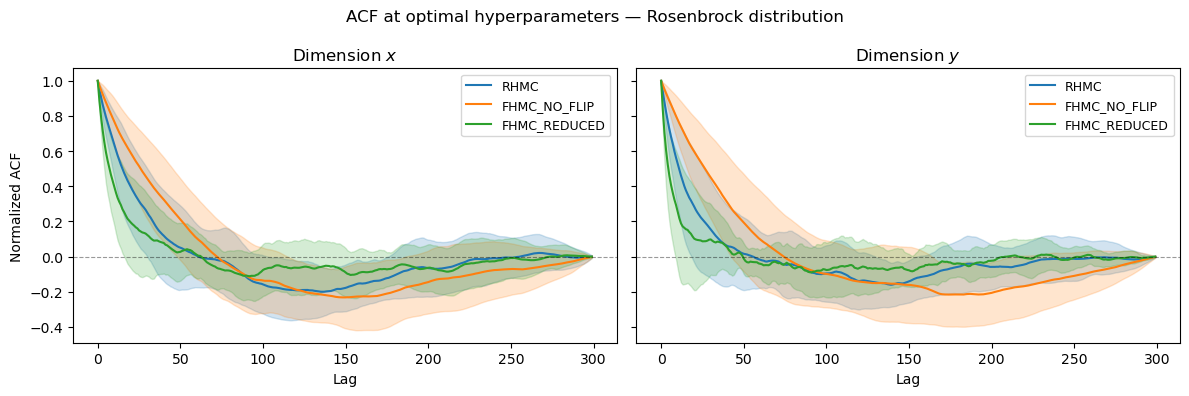

In [21]:
import matplotlib.pyplot as plt

ACF_KWARGS = dict(N_batch=20, N_run=300)
MAX_LAG    = 300

COLORS     = {"RHMC": "C0", "FHMC_NO_FLIP": "C1", "FHMC_REDUCED": "C2"}
DIM_LABELS = ["$x$", "$y$"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for name, cfg in ALGORITHMS.items():
    best_x = torch.tensor([optimal_params[name]["params"][k] for k in cfg["param_names"]])
    sampler = cfg["sampler_factory"](best_x, ACF_KWARGS["N_run"])
    z_0     = torch.randn(ACF_KWARGS["N_batch"], 2)

    tqdm.tqdm.write(f"Sampling {name} for ACF plot...")
    traj    = sampler.sample(z_0, return_traj=True, progress=True)
    samples = traj[:, 1:]                              # (B, N_run, 2)
    B, N, _ = samples.shape
    max_lag  = min(MAX_LAG, N)

    # Normalized ACF per chain — (B, max_lag, 2)
    acf_curves = []
    for b in range(B):
        g   = acf(samples[b])[:max_lag]               # (max_lag, 2)
        rho = g / g[0].abs().clamp(min=1e-10)
        acf_curves.append(rho)
    acf_curves = torch.stack(acf_curves).detach()      # (B, max_lag, 2)

    lags = torch.arange(max_lag).numpy()
    c    = COLORS[name]

    for dim_idx, (ax, dim_label) in enumerate(zip(axes, DIM_LABELS)):
        vals     = acf_curves[:, :, dim_idx]           # (B, max_lag)
        mean_acf = vals.mean(dim=0).numpy()
        std_acf  = vals.std(dim=0).numpy()
        ax.plot(lags, mean_acf, label=name, color=c, lw=1.5)
        ax.fill_between(lags, mean_acf - std_acf, mean_acf + std_acf,
                        alpha=0.2, color=c)

for ax, dim_label in zip(axes, DIM_LABELS):
    ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.4)
    ax.set_xlabel("Lag")
    ax.set_title(f"Dimension {dim_label}")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Normalized ACF")
fig.suptitle("ACF at optimal hyperparameters — Rosenbrock distribution")
plt.tight_layout()
plt.show()
